In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/sample_submission.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv
/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv


In [2]:
# %pip install transformers optuna matplotlib scikit-learn pandas numpy torch

import pandas as pd
import numpy as np
import torch
import os
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizerFast, BertForSequenceClassification,
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup, AutoConfig 
)
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import random
import matplotlib.pyplot as plt
import optuna 

2025-06-09 11:35:23.804998: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749468924.051882      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749468924.122243      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# --- 1. Global Settings (some will be overridden by Optuna within trials) ---
RANDOM_SEED = 42

def set_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# --- 2. Φόρτωση Δεδομένων (Load data once globally) ---
source_dir = r"/kaggle/input/ai-2-dl-for-nlp-2025-homework-3" 
try:
    train_df = pd.read_csv(os.path.join(source_dir, "train_dataset.csv"))
    test_df = pd.read_csv(os.path.join(source_dir, "test_dataset.csv"))
    val_df = pd.read_csv(os.path.join(source_dir, "val_dataset.csv"))
except FileNotFoundError:
    print(f"⚠️ Error: Data files not found in {source_dir}. Please check the path.")
    exit()

TEXT_COLUMN = 'Text'
LABEL_COLUMN = 'Label'
ID_COLUMN = 'ID'

if train_df.empty or val_df.empty:
    raise ValueError("Training or Validation DataFrame is empty. Optuna needs validation data.")

train_texts_global = train_df[TEXT_COLUMN].tolist()
train_labels_global = train_df[LABEL_COLUMN].tolist()
val_texts_global = val_df[TEXT_COLUMN].tolist()
val_labels_global = val_df[LABEL_COLUMN].tolist()
test_texts_global = test_df[TEXT_COLUMN].tolist() 

num_labels_global = train_df[LABEL_COLUMN].nunique()
print(f"Number of unique labels found: {num_labels_global}")

Number of unique labels found: 2


In [5]:
# --- 3. Dataset Class (Remains the same) ---
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        inputs = self.tokenizer.encode_plus(
            text, None, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        ids = inputs['input_ids'].flatten()
        mask = inputs['attention_mask'].flatten()

        if self.labels is not None:
            label = self.labels[item]
            return {'input_ids': ids, 'attention_mask': mask, 'labels': torch.tensor(label, dtype=torch.long)}
        else:
            return {'input_ids': ids, 'attention_mask': mask}

In [6]:
# --- 4. Συνάρτηση Εκπαίδευσης (Modified to accept grad_clip_norm) --
def train_epoch(model, data_loader, optimizer, device, scheduler, grad_clip_norm=1.0):
    model.train()
    total_loss = 0
    for batch_num, batch in enumerate(data_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm) 
        optimizer.step()
        scheduler.step()
    avg_train_loss = total_loss / len(data_loader)
    return avg_train_loss

In [7]:
# --- 5. Συνάρτηση Αξιολόγησης (Remains the same) ---
def eval_model(model, data_loader, device):
    model.eval()
    predictions_list = []
    actual_labels_list = []
    total_eval_loss = 0
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            total_eval_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions_list.extend(preds)
            actual_labels_list.extend(labels.cpu().numpy())
    avg_val_loss = total_eval_loss / len(data_loader)
    accuracy = accuracy_score(actual_labels_list, predictions_list)
    precision, recall, f1, _ = precision_recall_fscore_support(actual_labels_list, predictions_list, average='weighted', zero_division=0)
    return avg_val_loss, accuracy, precision, recall, f1

In [8]:
# --- 6. Optuna Objective Function ---
def objective(trial: optuna.trial.Trial):
    set_seed(RANDOM_SEED)

    # --- Hyperparameters to be tuned by Optuna ---
    model_type_choice = trial.suggest_categorical("model_type", ['bert']) 
    learning_rate = trial.suggest_float("learning_rate", 1e-6, 5e-5, log=True) # Slightly smaller LR range
    batch_size = trial.suggest_categorical("batch_size", [4, 8, 16, 32]) # Even smaller batch sizes
    epochs_trial = trial.suggest_int("epochs", 2, 3, 4) # Fewer epochs
    max_length_trial = trial.suggest_categorical("max_length", [32, 64]) # Shorter sequence length
    optimizer_eps = trial.suggest_float("optimizer_eps", 1e-9, 1e-7, log=True)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.0, 0.1) # Less warmup
    grad_clip_norm_trial = trial.suggest_float("grad_clip_norm", 0.5, 1.5)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.05)

    # Optional: Tune dropout rates - if still failing, consider fixing these to default 0.1 for now
    attention_dropout = trial.suggest_float("attention_dropout", 0.1, 0.2)
    hidden_dropout = trial.suggest_float("hidden_dropout", 0.1, 0.2)

    print(f"\nTrial {trial.number}: Testing with params: {trial.params}")

    # --- Tokenizer and Model (based on trial) ---
    if model_type_choice == 'bert':
        tokenizer_name = 'bert-base-uncased'
        model_pretrained_name = 'bert-base-uncased'
        model_class_trial = BertForSequenceClassification
        tokenizer_trial = BertTokenizerFast.from_pretrained(tokenizer_name)
    else: # distilbert
        tokenizer_name = 'distilbert-base-uncased'
        model_pretrained_name = 'distilbert-base-uncased'
        model_class_trial = DistilBertForSequenceClassification
        tokenizer_trial = DistilBertTokenizerFast.from_pretrained(tokenizer_name)

    # --- Datasets and DataLoaders (using trial's batch_size and max_length) ---
    train_dataset_trial = TweetDataset(train_texts_global, train_labels_global, tokenizer_trial, max_length_trial)
    train_loader_trial = DataLoader(train_dataset_trial, batch_size=batch_size, shuffle=True, num_workers=0)

    val_dataset_trial = TweetDataset(val_texts_global, val_labels_global, tokenizer_trial, max_length_trial)
    val_loader_trial = DataLoader(val_dataset_trial, batch_size=batch_size, shuffle=False, num_workers=0)

    # --- Model Loading (inside objective) ---
    config_trial = AutoConfig.from_pretrained(
        model_pretrained_name,
        num_labels=num_labels_global,
        attention_probs_dropout_prob=attention_dropout, 
        hidden_dropout_prob=hidden_dropout            
    )
    model_trial = model_class_trial.from_pretrained(model_pretrained_name, config=config_trial)
    model_trial.to(device)

    # --- Optimizer and Scheduler ---
    optimizer_trial = AdamW(model_trial.parameters(), lr=learning_rate, eps=optimizer_eps, weight_decay=weight_decay)
    total_steps_trial = len(train_loader_trial) * epochs_trial
    num_warmup_steps_trial = int(total_steps_trial * warmup_ratio)
    scheduler_trial = get_linear_schedule_with_warmup(
        optimizer_trial, num_warmup_steps=num_warmup_steps_trial, num_training_steps=total_steps_trial
    )

    best_val_f1_trial = 0.0 

    # --- Training and Evaluation Loop for the current trial ---
    for epoch in range(epochs_trial):
        _ = train_epoch(model_trial, train_loader_trial, optimizer_trial, device, scheduler_trial, grad_clip_norm_trial)
        
        val_loss, val_accuracy, _, _, val_f1 = eval_model(model_trial, val_loader_trial, device)
        print(f"    Trial {trial.number} - Epoch {epoch+1}/{epochs_trial} - Val F1: {val_f1:.4f}, Val Acc: {val_accuracy:.4f}")
        trial.report(val_f1, epoch)

        if trial.should_prune():
            print(f"    Trial {trial.number} pruned at epoch {epoch+1}.")
            raise optuna.exceptions.TrialPruned()
        
        if val_f1 > best_val_f1_trial: 
             best_val_f1_trial = val_f1

    print(f"  Trial {trial.number} completed. Best Val F1: {best_val_f1_trial:.4f}")
    return best_val_f1_trial


# Note 1

**Please uncomment the "7. Optuna Study Execution" to start the study and let optuna find the optimized hyperparameters and add them to the "best_params" variable**

In [9]:
# # --- 7. Optuna Study Execution ---
# N_TRIALS = 25  

# pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1, interval_steps=1)

# study = optuna.create_study(direction="maximize", pruner=pruner)
# try:
#     set_seed(42)
#     study.optimize(objective, n_trials=N_TRIALS,  show_progress_bar=True)
# except KeyboardInterrupt:
#     print("Optuna optimization stopped")
    
# print("\nOptuna optimization finished")
# print("Number of finished trials: ", len(study.trials))

# print("\nBest trial found: ")
# best_trial = study.best_trial
# print(f"  Value (Max Validation F1): {best_trial.value:.4f}")
# print("  Best Hyperparameters: ")
# for key, value in best_trial.params.items():
#     print(f"    {key}: {value}")

# study_results_df = study.trials_dataframe()
# study_results_df.to_csv("optuna_study_results_v2.csv", index=False)
# print("\nOptuna study results saved to optuna_study_results_v2.csv")

# best_params = best_trial.params

# Note 2

**Here is the best parameters that I find localy and because I don'thave enough time in kaggle to run it I just put the best params directly to the model to run it for the submission. Please when you comment out the part 7. Optuna Study Execution, comment out the above part of the code. Thank you and sorry for the extra steps.**   😅

In [10]:
# best params from previous optuna results
best_params = {
    "model_type": "bert",
    "learning_rate": 1.739034610946433e-05,
    "batch_size": 16,
    "epochs": 2,
    "max_length": 64,
    "optimizer_eps": 1.6738492968697837e-09,
    "warmup_ratio": 0.01705170232834087,
    "grad_clip_norm": 1.2664528150131553,
    "weight_decay": 0.0071473387359451855,
    "attention_dropout": 0.19337820442298004,
    "hidden_dropout": 0.18963381330830553
}

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting final training run with best parameters
Epoch 1/2
----------
  Training loss: 0.3944
  Validation loss: 0.3522
  Validation Accuracy: 0.8511
  Validation Precision: 0.8514
  Validation Recall: 0.8511
  Validation F1-Score: 0.8510

Epoch 2/2
----------
  Training loss: 0.3094
  Validation loss: 0.3616
  Validation Accuracy: 0.8554
  Validation Precision: 0.8554
  Validation Recall: 0.8554
  Validation F1-Score: 0.8554

Final training complete


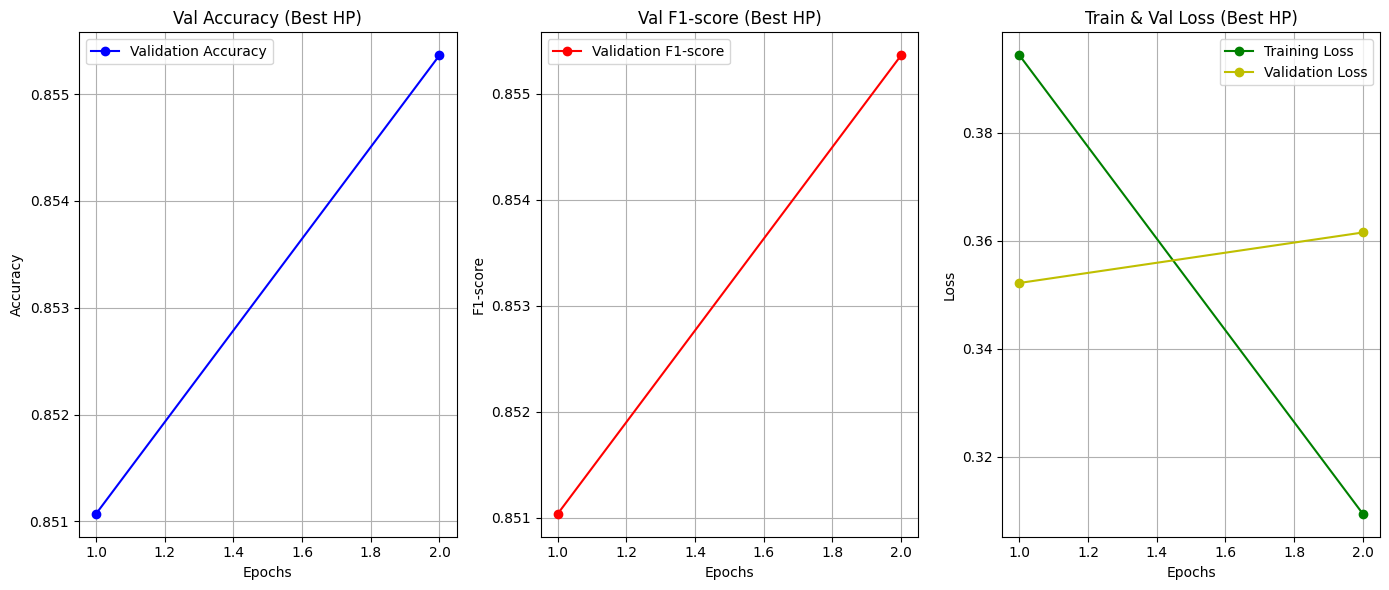

In [11]:
# --- 8. (Optional) Re-train with Best Hyperparameters and Full Evaluation ---
# Get best hyperparameters from the study
# best_params = best_trial.params
final_model_type = best_params['model_type']
final_lr = best_params['learning_rate']
final_batch_size = best_params['batch_size']
final_epochs = best_params.get('epochs', 5) 
final_max_length = best_params['max_length']
final_optimizer_eps = best_params['optimizer_eps']
final_warmup_ratio = best_params['warmup_ratio']
final_grad_clip_norm = best_params['grad_clip_norm']
final_weight_decay = best_params['weight_decay']
final_attention_dropout = best_params.get('attention_dropout', 0.1) 
final_hidden_dropout = best_params.get('hidden_dropout', 0.1)   

set_seed(RANDOM_SEED)

if final_model_type == 'bert':
    final_tokenizer_name = 'bert-base-uncased'
    final_model_pretrained_name = 'bert-base-uncased'
    final_model_class = BertForSequenceClassification
    final_tokenizer = BertTokenizerFast.from_pretrained(final_tokenizer_name)
else:
    final_tokenizer_name = 'distilbert-base-uncased'
    final_model_pretrained_name = 'distilbert-base-uncased'
    final_model_class = DistilBertForSequenceClassification
    final_tokenizer = DistilBertTokenizerFast.from_pretrained(final_tokenizer_name)

final_config = AutoConfig.from_pretrained(
    final_model_pretrained_name,
    num_labels=num_labels_global,
    attention_probs_dropout_prob=final_attention_dropout, 
    hidden_dropout_prob=final_hidden_dropout             
)
final_model = final_model_class.from_pretrained(final_model_pretrained_name, config=final_config)
final_model.to(device)

final_train_dataset = TweetDataset(train_texts_global, train_labels_global, final_tokenizer, final_max_length)
final_train_loader = DataLoader(final_train_dataset, batch_size=final_batch_size, shuffle=True, num_workers=0)

final_val_dataset = TweetDataset(val_texts_global, val_labels_global, final_tokenizer, final_max_length)
final_val_loader = DataLoader(final_val_dataset, batch_size=final_batch_size, shuffle=False, num_workers=0)

final_optimizer = AdamW(final_model.parameters(), lr=final_lr, eps=final_optimizer_eps, weight_decay=final_weight_decay)
final_total_steps = len(final_train_loader) * final_epochs
final_num_warmup_steps = int(final_total_steps * final_warmup_ratio)
final_scheduler = get_linear_schedule_with_warmup(
    final_optimizer, num_warmup_steps=final_num_warmup_steps, num_training_steps=final_total_steps
)

# --- Actual Final Training Loop (with plotting) ---
train_losses, val_losses, val_accuracies, val_f1_scores = [], [], [], []

print("Starting final training run with best parameters")
for epoch in range(final_epochs):
    print(f'Epoch {epoch + 1}/{final_epochs}')
    print('-' * 10)

    avg_train_loss = train_epoch(final_model, final_train_loader, final_optimizer, device, final_scheduler, final_grad_clip_norm)
    train_losses.append(avg_train_loss)
    print(f'  Training loss: {avg_train_loss:.4f}')

    avg_val_loss, val_accuracy, val_precision, val_recall, val_f1 = eval_model(final_model, final_val_loader, device)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    val_f1_scores.append(val_f1)

    print(f'  Validation loss: {avg_val_loss:.4f}')
    print(f'  Validation Accuracy: {val_accuracy:.4f}')
    print(f'  Validation Precision: {val_precision:.4f}')
    print(f'  Validation Recall: {val_recall:.4f}')
    print(f'  Validation F1-Score: {val_f1:.4f}\n')
print("Final training complete")

# --- Plotting ---
if final_epochs > 0:
    epochs_range = range(1, final_epochs + 1)
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, val_accuracies, 'bo-', label='Validation Accuracy')
    plt.title('Val Accuracy (Best HP)')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, val_f1_scores, 'ro-', label='Validation F1-score')
    plt.title('Val F1-score (Best HP)')
    plt.xlabel('Epochs'); plt.ylabel('F1-score'); plt.legend(); plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, train_losses, 'go-', label='Training Loss')
    plt.plot(epochs_range, val_losses, 'yo-', label='Validation Loss')
    plt.title('Train & Val Loss (Best HP)')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    
    plt.tight_layout(); plt.show()

In [12]:
# --- 9. Πρόβλεψη στο Test Set (using the final_model) ---
def get_test_predictions(model, tokenizer_final, max_len_final, batch_size_final, device_final):
    model.eval()
    predictions = []

    test_dataset_final = TweetDataset(test_texts_global, labels=None, tokenizer=tokenizer_final, max_len=max_len_final)
    test_loader_final = DataLoader(test_dataset_final, batch_size=batch_size_final, shuffle=False, num_workers=0)

    with torch.no_grad():
        for batch in test_loader_final:
            input_ids = batch['input_ids'].to(device_final)
            attention_mask = batch['attention_mask'].to(device_final)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            predictions.extend(preds)

    return predictions


# Generate predictions
final_test_predictions = get_test_predictions(
    final_model,
    tokenizer_final=final_tokenizer,
    max_len_final=final_max_length,
    batch_size_final=final_batch_size,
    device_final=device
)



In [13]:
print("\nMaking predictions on the test set with the best model")
test_predictions = get_test_predictions(final_model, final_tokenizer, final_max_length, final_batch_size, device)

# --- 10. Δημιουργία Αρχείου Υποβολής ---
submission = pd.DataFrame({
    ID_COLUMN: test_df[ID_COLUMN],
    LABEL_COLUMN: test_predictions
})
submission.to_csv('submission.csv', index=False)
print(f"submission.csv created successfully")


Making predictions on the test set with the best model
submission.csv created successfully
